# Home Credit Default Risk: Comprehensive Source Data Profiling, Business Semantics & DE Action Proposals

## Notebook Purpose for Data Engineers
Before writing ETL pipelines (Raw $\rightarrow$ Stage $\rightarrow$ Curated) in PySpark, a Data Engineer must answer three fundamental questions for every column in the source dataset:
1. **What data types and distributions exist?** (Raw inferred dtypes, null rate, cardinality, sample values, min/max)
2. **What is the business meaning?** (Financial domain context, repayment semantics, credit bureau records from `HomeCredit_columns_description.csv`)
3. **What is the Data Engineering proposal?** (Storage type casting, precision preservation `Decimal(18,2)`, sentinel value cleanup `365243`, dimensional extraction, surrogate key hashing `xxhash64`, and `-1` unknown member fallback)

```
Source Tables Scope:
├── application_{train|test}.csv  : Core customer loan applications & default labels
├── bureau.csv                   : External credit accounts reported by other banks
├── bureau_balance.csv           : Monthly status history of external credit accounts
├── previous_application.csv     : Historical loan applications with Home Credit
├── installments_payments.csv    : Scheduled vs actual repayment cashflow transactions
├── POS_CASH_balance.csv         : Monthly balance & DPD for point-of-sale consumer loans
└── credit_card_balance.csv      : Monthly balance, credit limit & drawings for credit cards
```

In [16]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting and display options
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Dynamic dataset path resolution
POSSIBLE_DIRS = [
    Path('data/home-credit-default-risk'),
    Path('../data/home-credit-default-risk'),
    Path('../../data/home-credit-default-risk')
]
DATA_DIR = next((d for d in POSSIBLE_DIRS if d.exists()), None)
if DATA_DIR:
    print(f'[SUCCESS] Raw dataset found at: {DATA_DIR.resolve()}')
else:
    raise FileNotFoundError('Dataset directory not found in candidate paths.')

def safe_read_csv(filepath, **kwargs):
    '''Reads CSV using UTF-8, falling back to latin1 if UnicodeDecodeError occurs.'''
    try:
        return pd.read_csv(filepath, **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(filepath, encoding='latin1', **kwargs)


[SUCCESS] Raw dataset found at: D:\Projects\hadoop-spark-yarn\data\home-credit-default-risk


---
## 1. Automated Column Profiling & DE Action Engine

We build a reusable profiling engine that inspects every column in a table, computes statistical properties, joins official business definitions from `HomeCredit_columns_description.csv`, and automatically produces **concrete Data Engineering proposals**.

In [17]:
# Load official Data Dictionary
desc_file = DATA_DIR / 'HomeCredit_columns_description.csv'
if desc_file.exists():
    desc_df = pd.read_csv(desc_file, encoding='latin1')
    print(f'Loaded {len(desc_df)} column descriptions from dictionary.')
else:
    desc_df = pd.DataFrame(columns=['Table', 'Row', 'Description'])
    print('Warning: Data dictionary file not found.')

def profile_table_columns(df, table_name, desc_df=desc_df):
    """
    Comprehensive Data Engineering Profiler:
    Computes null rate, cardinality, domain classification, business meaning, and DE proposal.
    """
    profiles = []
    total_rows = len(df)
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        null_count = int(df[col].isnull().sum())
        null_pct = round(null_count / total_rows * 100, 2)
        n_unique = int(df[col].nunique(dropna=True))
        
        # Fetch business description
        desc = 'N/A'
        if not desc_df.empty:
            matches = desc_df[desc_df['Row'] == col]
            if len(matches) > 0:
                desc = str(matches.iloc[0]['Description'])
        
        # Classify business domain & formulate engineering proposal
        col_upper = col.upper()
        if col_upper.startswith('SK_ID'):
            domain = 'Identifier (Key)'
            target_type = 'INT / BIGINT'
            action = 'Stage: Retain natural key. Curated: Use xxhash64 for Surrogate Key; broadcast join dimensions.'
        elif col_upper.startswith('AMT_'):
            domain = 'Monetary Amount'
            target_type = 'DECIMAL(18,2)'
            action = 'Enforce Decimal(18,2) in Hive & Decimal64(2) in ClickHouse. Prohibit Float to avoid rounding errors.'
        elif col_upper.startswith('DAYS_') or col_upper == 'MONTHS_BALANCE':
            domain = 'Temporal Offset'
            target_type = 'INT'
            if col_upper == 'DAYS_EMPLOYED':
                action = 'CRITICAL: Flag 365243 as sentinel anomaly; replace with NULL or create is_pensioner boolean.'
            elif col_upper == 'DAYS_BIRTH':
                action = 'Derive age_years = floor(DAYS_BIRTH / -365.25) in Stage; store as clean integer.'
            else:
                action = 'Relative day/month offset. Validate negative bounds; partition pruning candidate.'
        elif col_upper.startswith('CNT_') or col_upper.startswith('NUM_'):
            domain = 'Count / Sequence'
            target_type = 'INT'
            action = 'Cast to INT; fill NULL with 0 for cumulative count metrics.'
        elif col_upper.startswith('FLAG_') or col_upper.startswith('IS_') or col_upper == 'TARGET':
            domain = 'Binary Flag'
            target_type = 'INT / BOOLEAN'
            action = 'Standardize to 0/1 integer or boolean; optimize as UInt8 in ClickHouse.'
        elif col_upper.startswith('RATE_') or 'RATIO' in col_upper:
            domain = 'Financial Ratio'
            target_type = 'DECIMAL(8,6)'
            action = 'Cast to fixed Decimal(8,6) for interest rates & down-payment ratios.'
        elif 'EXT_SOURCE' in col_upper:
            domain = 'Credit Risk Score'
            target_type = 'FLOAT'
            action = 'Normalized external score [0.0, 1.0]. Retain in Feature Store; impute with median for ML.'
        elif dtype == 'object':
            domain = 'Categorical'
            target_type = 'STRING / LowCardinality'
            if n_unique <= 30:
                action = f'Low cardinality ({n_unique} distinct). Candidate for conformed dimension; LowCardinality(String) in ClickHouse.'
            else:
                action = f'High cardinality text ({n_unique} distinct). Trim whitespace; uppercase standardize.'
        else:
            domain = 'Numeric Metric'
            target_type = dtype
            action = 'Validate range and outliers; check correlation with TARGET.'
            
        sample_vals = df[col].dropna().unique()[:3]
        samples_str = ', '.join([str(x) for x in sample_vals])
        
        profiles.append({
            'Column': col,
            'Raw Type': dtype,
            'Null %': null_pct,
            'Distinct': n_unique,
            'Business Domain': domain,
            'Target DDL Type': target_type,
            'Samples': samples_str[:35],
            'Business Meaning': desc,
        })
        
    return pd.DataFrame(profiles)

print('Profiler Engine successfully initialized.')

Loaded 219 column descriptions from dictionary.
Profiler Engine successfully initialized.


---
## 2. Source Files Inventory & Physical Storage

Summary of raw files, sizes on disk, row counts, and column widths.

In [18]:
file_metrics = []
csv_files = sorted(DATA_DIR.glob('*.csv'))

for f in csv_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    with open(f, 'rb') as fp:
        lines = sum(chunk.count(b'\n') for chunk in iter(lambda: fp.read(1024 * 1024), b''))
    df_sample = safe_read_csv(f, nrows=2)
    cols = len(df_sample.columns)
    
    file_metrics.append({
        'File Name': f.name,
        'Size (MB)': round(size_mb, 2),
        'Total Rows': max(0, lines - 1),
        'Columns': cols
    })

inventory_df = pd.DataFrame(file_metrics).sort_values(by='Size (MB)', ascending=False).reset_index(drop=True)
display(inventory_df)

,File Name,Size (MB),Total Rows,Columns
0,installments_payments.csv,689.62,13605401,8
1,credit_card_balance.csv,404.91,3840312,23
2,previous_application.csv,386.21,1670214,37
3,POS_CASH_balance.csv,374.51,10001358,8
4,bureau_balance.csv,358.19,27299925,3
5,bureau.csv,162.14,1716428,17
6,application_train.csv,158.44,307511,122
7,application_test.csv,25.34,48744,121
8,sample_submission.csv,0.51,48744,2
9,HomeCredit_columns_description.csv,0.04,219,5


---
## 3. Core Customer Applications (`application_train.csv`)

This is the central loan origination entity (307,511 rows, 122 columns). Below is the comprehensive profiling across all columns, categorized by business domain with recommended DE actions.

In [19]:
# Load sample of application_train for deep profiling
app_train = safe_read_csv(DATA_DIR / 'application_train.csv', nrows=50000)
app_profile = profile_table_columns(app_train, 'application_train')

print(f'Total Columns: {len(app_profile)}')
print('Breakdown of columns by Business Domain:')
display(app_profile['Business Domain'].value_counts())

# Show profile of key demographic, financial, and risk score columns
key_cols = [
    'SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'AMT_INCOME_TOTAL',
    'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1',
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'
]
display(app_profile[app_profile['Column'].isin(key_cols)][['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']])

Total Columns: 122
Breakdown of columns by Business Domain:


Business Domain
Numeric Metric       58
Binary Flag          29
Categorical          14
Monetary Amount      10
Temporal Offset       5
Credit Risk Score     3
Count / Sequence      2
Identifier (Key)      1
Name: count, dtype: int64

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_CURR,int64,0.00,Identifier (Key),INT / BIGINT,ID of loan in our sample
1,TARGET,int64,0.00,Binary Flag,INT / BOOLEAN,Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of t...
2,NAME_CONTRACT_TYPE,object,0.00,Categorical,STRING / LowCardinality,Identification if loan is cash or revolving
3,CODE_GENDER,object,0.00,Categorical,STRING / LowCardinality,Gender of the client
7,AMT_INCOME_TOTAL,float64,0.00,Monetary Amount,"DECIMAL(18,2)",Income of the client
8,AMT_CREDIT,float64,0.00,Monetary Amount,"DECIMAL(18,2)",Credit amount of the loan
9,AMT_ANNUITY,float64,0.00,Monetary Amount,"DECIMAL(18,2)",Loan annuity
12,NAME_INCOME_TYPE,object,0.00,Categorical,STRING / LowCardinality,"Clients income type (businessman, working, maternity leave, )"
13,NAME_EDUCATION_TYPE,object,0.00,Categorical,STRING / LowCardinality,Level of highest education the client achieved
17,DAYS_BIRTH,int64,0.00,Temporal Offset,INT,Client's age in days at the time of application


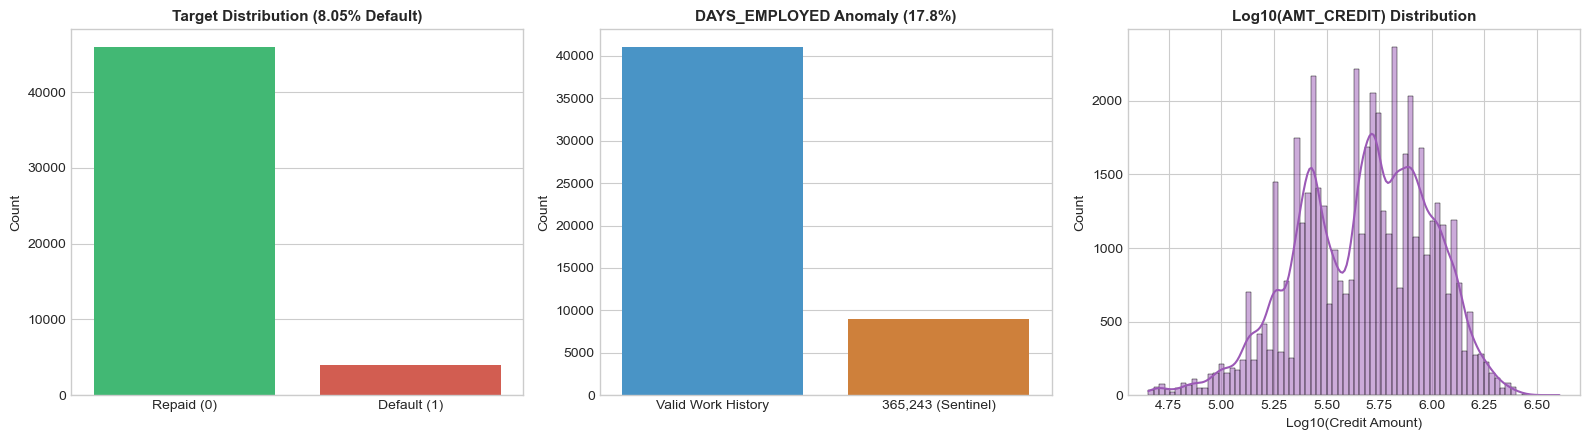

In [20]:
# Visualizing Class Imbalance, Anomaly in Employment, and Financial Scales
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Target Imbalance
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100
sns.barplot(x=['Repaid (0)', 'Default (1)'], y=target_counts.values, ax=axes[0], hue=['Repaid (0)', 'Default (1)'], palette=['#2ecc71', '#e74c3c'], legend=False)
axes[0].set_title(f'Target Distribution ({target_pct[1]:.2f}% Default)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

# 2. Critical Anomaly: DAYS_EMPLOYED == 365243
anom_count = (app_train['DAYS_EMPLOYED'] == 365243).sum()
sns.barplot(x=['Valid Work History', '365,243 (Sentinel)'], y=[len(app_train) - anom_count, anom_count], ax=axes[1], hue=['Valid Work History', '365,243 (Sentinel)'], palette=['#3498db', '#e67e22'], legend=False)
axes[1].set_title(f'DAYS_EMPLOYED Anomaly ({anom_count/len(app_train)*100:.1f}%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')

# 3. Financial Amount Scale (Log-transformed Credit Amount)
sns.histplot(np.log10(app_train['AMT_CREDIT'].dropna()), kde=True, ax=axes[2], color='#9b59b6')
axes[2].set_title('Log10(AMT_CREDIT) Distribution', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Log10(Credit Amount)')

plt.tight_layout()
plt.show()

---
## 4. External Credit Bureau: `bureau.csv` & `bureau_balance.csv`

- **Business Context**: Tracks credit lines issued by competitor financial institutions, active vs closed debts, and monthly delinquency repayment histories.

In [21]:
bureau = safe_read_csv(DATA_DIR / 'bureau.csv', nrows=50000)
bureau_profile = profile_table_columns(bureau, 'bureau')
display(bureau_profile[['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']])

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_CURR,int64,0.00,Identifier (Key),INT / BIGINT,ID of loan in our sample
1,SK_ID_BUREAU,int64,0.00,Identifier (Key),INT / BIGINT,N/A
2,CREDIT_ACTIVE,object,0.00,Categorical,STRING / LowCardinality,Status of the Credit Bureau (CB) reported credits
3,CREDIT_CURRENCY,object,0.00,Categorical,STRING / LowCardinality,Recoded currency of the Credit Bureau credit
4,DAYS_CREDIT,int64,0.00,Temporal Offset,INT,How many days before current application did client apply for Credit Bureau credit
5,CREDIT_DAY_OVERDUE,int64,0.00,Numeric Metric,int64,Number of days past due on CB credit at the time of application for related loan in our sample
6,DAYS_CREDIT_ENDDATE,float64,6.30,Temporal Offset,INT,Remaining duration of CB credit (in days) at the time of application in Home Credit
7,DAYS_ENDDATE_FACT,float64,38.44,Temporal Offset,INT,Days since CB credit ended at the time of application in Home Credit (only for closed credit)
8,AMT_CREDIT_MAX_OVERDUE,float64,64.05,Monetary Amount,"DECIMAL(18,2)",Maximal amount overdue on the Credit Bureau credit so far (at application date of loan in our sample)
9,CNT_CREDIT_PROLONG,int64,0.00,Count / Sequence,INT,How many times was the Credit Bureau credit prolonged


In [22]:
bureau_bal = safe_read_csv(DATA_DIR / 'bureau_balance.csv', nrows=100000)
bureau_bal_profile = profile_table_columns(bureau_bal, 'bureau_balance')
display(bureau_bal_profile[['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']])

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_BUREAU,int64,0.00,Identifier (Key),INT / BIGINT,N/A
1,MONTHS_BALANCE,int64,0.00,Temporal Offset,INT,Month of balance relative to application date (-1 means the freshest balance date)
2,STATUS,object,0.00,Categorical,STRING / LowCardinality,"Status of Credit Bureau loan during the month (active, closed, DPD0-30, [C means closed, X means status unknown, 0 ..."


---
## 5. Previous Applications & Historical Funnel (`previous_application.csv`)

- **Business Context**: Tracks previous internal loan applications, underwriting decision outcomes (Approved, Refused, Canceled), rejection reasons, and partner store channels.

In [23]:
prev_app = safe_read_csv(DATA_DIR / 'previous_application.csv', nrows=50000)
prev_profile = profile_table_columns(prev_app, 'previous_application')
display(prev_profile[['Column', 'Raw Type', 'Null %', 'Distinct', 'Business Domain', 'Target DDL Type', 'Business Meaning']].head(20))

,Column,Raw Type,Null %,Distinct,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_PREV,int64,0.00,50000,Identifier (Key),INT / BIGINT,N/A
1,SK_ID_CURR,int64,0.00,44471,Identifier (Key),INT / BIGINT,ID of loan in our sample
2,NAME_CONTRACT_TYPE,object,0.00,4,Categorical,STRING / LowCardinality,Identification if loan is cash or revolving
3,AMT_ANNUITY,float64,21.18,28731,Monetary Amount,"DECIMAL(18,2)",Loan annuity
4,AMT_APPLICATION,float64,0.00,13551,Monetary Amount,"DECIMAL(18,2)",For how much credit did client ask on the previous application
5,AMT_CREDIT,float64,0.00,18800,Monetary Amount,"DECIMAL(18,2)",Credit amount of the loan
6,AMT_DOWN_PAYMENT,float64,50.40,4332,Monetary Amount,"DECIMAL(18,2)",Down payment on the previous application
7,AMT_GOODS_PRICE,float64,21.49,13551,Monetary Amount,"DECIMAL(18,2)",For consumer loans it is the price of the goods for which the loan is given
8,WEEKDAY_APPR_PROCESS_START,object,0.00,7,Categorical,STRING / LowCardinality,On which day of the week did the client apply for the loan
9,HOUR_APPR_PROCESS_START,int64,0.00,24,Numeric Metric,int64,Approximately at what hour did the client apply for the loan


---
## 6. Granular Repayment Cashflows (`installments_payments.csv`)

- **Business Context**: Contains actual payment transactions versus scheduled payment terms. Critical for computing payment delays and underpayments.

In [24]:
inst = safe_read_csv(DATA_DIR / 'installments_payments.csv', nrows=50000)
inst_profile = profile_table_columns(inst, 'installments_payments')
display(inst_profile[['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']])

# Derived Metric Calculations for DE Pipeline
inst['delay_days'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['underpayment'] = np.maximum(0, inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT'])

print(f'Installments paid late (delay > 0)    : {(inst["delay_days"] > 0).mean()*100:.2f}%')
print(f'Installments underpaid (shortfall > 0): {(inst["underpayment"] > 0).mean()*100:.2f}%')

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_PREV,int64,0.00,Identifier (Key),INT / BIGINT,N/A
1,SK_ID_CURR,int64,0.00,Identifier (Key),INT / BIGINT,ID of loan in our sample
2,NUM_INSTALMENT_VERSION,float64,0.00,Count / Sequence,INT,Version of installment calendar (0 is for credit card) of previous credit. Change of installment version from month ...
3,NUM_INSTALMENT_NUMBER,int64,0.00,Count / Sequence,INT,On which installment we observe payment
4,DAYS_INSTALMENT,float64,0.00,Temporal Offset,INT,When the installment of previous credit was supposed to be paid (relative to application date of current loan)
5,DAYS_ENTRY_PAYMENT,float64,0.00,Temporal Offset,INT,When was the installments of previous credit paid actually (relative to application date of current loan)
6,AMT_INSTALMENT,float64,0.00,Monetary Amount,"DECIMAL(18,2)",What was the prescribed installment amount of previous credit on this installment
7,AMT_PAYMENT,float64,0.00,Monetary Amount,"DECIMAL(18,2)",What the client actually paid on previous credit on this installment


Installments paid late (delay > 0)    : 8.61%
Installments underpaid (shortfall > 0): 9.81%


---
## 7. Monthly Snapshot Ledgers (`POS_CASH_balance.csv` & `credit_card_balance.csv`)

- **Business Context**: Longitudinal monthly contract statuses, Days Past Due (`SK_DPD`), and credit limit drawings/utilization.

In [25]:
pos = safe_read_csv(DATA_DIR / 'POS_CASH_balance.csv', nrows=50000)
pos_profile = profile_table_columns(pos, 'POS_CASH_balance')
display(pos_profile[['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']])

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_PREV,int64,0.00,Identifier (Key),INT / BIGINT,N/A
1,SK_ID_CURR,int64,0.00,Identifier (Key),INT / BIGINT,ID of loan in our sample
2,MONTHS_BALANCE,int64,0.00,Temporal Offset,INT,Month of balance relative to application date (-1 means the freshest balance date)
3,CNT_INSTALMENT,float64,0.14,Count / Sequence,INT,Term of previous credit (can change over time)
4,CNT_INSTALMENT_FUTURE,float64,0.14,Count / Sequence,INT,Installments left to pay on the previous credit
5,NAME_CONTRACT_STATUS,object,0.00,Categorical,STRING / LowCardinality,Contract status during the month
6,SK_DPD,int64,0.00,Numeric Metric,int64,DPD (days past due) during the month of previous credit
7,SK_DPD_DEF,int64,0.00,Numeric Metric,int64,DPD during the month with tolerance (debts with low loan amounts are ignored) of the previous credit


In [26]:
cc = safe_read_csv(DATA_DIR / 'credit_card_balance.csv', nrows=50000)
cc_profile = profile_table_columns(cc, 'credit_card_balance')
display(cc_profile[['Column', 'Raw Type', 'Null %', 'Business Domain', 'Target DDL Type', 'Business Meaning']].head(15))

,Column,Raw Type,Null %,Business Domain,Target DDL Type,Business Meaning
0,SK_ID_PREV,int64,0.00,Identifier (Key),INT / BIGINT,N/A
1,SK_ID_CURR,int64,0.00,Identifier (Key),INT / BIGINT,ID of loan in our sample
2,MONTHS_BALANCE,int64,0.00,Temporal Offset,INT,Month of balance relative to application date (-1 means the freshest balance date)
3,AMT_BALANCE,float64,0.00,Monetary Amount,"DECIMAL(18,2)",Balance during the month of previous credit
4,AMT_CREDIT_LIMIT_ACTUAL,int64,0.00,Monetary Amount,"DECIMAL(18,2)",Credit card limit during the month of the previous credit
5,AMT_DRAWINGS_ATM_CURRENT,float64,21.18,Monetary Amount,"DECIMAL(18,2)",Amount drawing at ATM during the month of the previous credit
6,AMT_DRAWINGS_CURRENT,float64,0.00,Monetary Amount,"DECIMAL(18,2)",Amount drawing during the month of the previous credit
7,AMT_DRAWINGS_OTHER_CURRENT,float64,21.18,Monetary Amount,"DECIMAL(18,2)",Amount of other drawings during the month of the previous credit
8,AMT_DRAWINGS_POS_CURRENT,float64,21.18,Monetary Amount,"DECIMAL(18,2)",Amount drawing or buying goods during the month of the previous credit
9,AMT_INST_MIN_REGULARITY,float64,5.85,Monetary Amount,"DECIMAL(18,2)",Minimal installment for this month of the previous credit


---
## 8. Relational Key Join Coverage & Orphan Analysis

We check join coverage between primary customer keys (`SK_ID_CURR`) and child tables (`bureau`, `previous_application`, `installments_payments`) to justify why the **`-1` Unknown Dimension Member pattern** is necessary.

In [27]:
# Check unique customer IDs across datasets
train_ids = set(safe_read_csv(DATA_DIR / 'application_train.csv', usecols=['SK_ID_CURR'])['SK_ID_CURR'])
test_ids = set(safe_read_csv(DATA_DIR / 'application_test.csv', usecols=['SK_ID_CURR'])['SK_ID_CURR'])
all_app_ids = train_ids.union(test_ids)

bureau_ids = set(safe_read_csv(DATA_DIR / 'bureau.csv', usecols=['SK_ID_CURR'])['SK_ID_CURR'])
prev_ids = set(safe_read_csv(DATA_DIR / 'previous_application.csv', usecols=['SK_ID_CURR'])['SK_ID_CURR'])

print(f'All Application Customer IDs : {len(all_app_ids):,}')
print(f'Bureau Customer IDs          : {len(bureau_ids):,} (In Application: {len(bureau_ids.intersection(all_app_ids))/len(bureau_ids)*100:.2f}%)')
print(f'Previous App Customer IDs    : {len(prev_ids):,} (In Application: {len(prev_ids.intersection(all_app_ids))/len(prev_ids)*100:.2f}%)')

# Application customers with NO bureau history
app_no_bureau = len(all_app_ids - bureau_ids)
print(f'Application customers with NO bureau records: {app_no_bureau:,} ({app_no_bureau/len(all_app_ids)*100:.2f}%)')

# Takeaway: ~14% of applicants have no prior bureau records!
# In dimensional modeling: Fact lookups MUST fallback to -1 (Unknown Member) to prevent row loss during INNER JOIN.

All Application Customer IDs : 356,255
Bureau Customer IDs          : 305,811 (In Application: 100.00%)
Previous App Customer IDs    : 338,857 (In Application: 100.00%)
Application customers with NO bureau records: 50,444 (14.16%)


---
## 9. Comprehensive Data Engineering Architecture Matrix

| Data Group | Source Columns Pattern | Business Semantics | Inferred Raw Type | Target DDL Type (Spark / ClickHouse) | Concrete DE Action & Transformation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Natural Business Keys** | `SK_ID_CURR`, `SK_ID_PREV`, `SK_ID_BUREAU` | Client & contract identifiers across banking systems | `int64` | `INT` / `UInt32` | Retain 1:1 in Stage. In Curated, hash with `xxhash64` for distributed Surrogate Keys. |
| **Monetary Amounts** | `AMT_CREDIT`, `AMT_BALANCE`, `AMT_PAYMENT`, `AMT_INCOME_TOTAL` | Disbursed loan amounts, monthly balances, transaction cashflows | `float64` | `DECIMAL(18,2)` / `Decimal64(2)` | Strictly cast to Decimal(18,2) to prevent floating-point rounding errors in financial ledgers. |
| **Employment Outlier** | `DAYS_EMPLOYED` | Days employed prior to application | `int64` | `INT` / `Int32` | Detect sentinel `365243` (~1000 yrs); replace with `NULL` or derive `is_pensioner = true`. |
| **Age Calculation** | `DAYS_BIRTH` | Days before application client was born (negative integer) | `int64` | `INT` / `UInt8` | Compute derived positive customer age: `floor(DAYS_BIRTH / -365.25)`. |
| **Repayment Delays** | `DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT` | Ledger repayment delay in days | Computed | `INT` / `Int16` | Positive value indicates delinquency; negative indicates early prepayment. |
| **Delinquency Status** | `STATUS` in `bureau_balance`, `SK_DPD` in snapshots | Days Past Due aging buckets (`0`, `30`, `60`, `90+ DPD`) | `object` / `int64` | `INT` (FK) / `UInt16` | Map raw codes (`C`, `0`..`5`) into conformed `dim_delinquency_bucket` with fallback `-1`. |
| **Low-Cardinality Dims** | `NAME_CONTRACT_TYPE`, `CODE_GENDER`, `CHANNEL_TYPE` | Product and distribution channels | `object` | `STRING` / `LowCardinality(String)` | Extract into conformed dimensions (`dim_loan_product`, `dim_merchant_channel`). Prepend `-1` default record. |
| **External Risk Scores** | `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` | Credit bureau risk scores normalized between 0.0 and 1.0 | `float64` | `FLOAT` / `Float32` | Retain in Curated Feature Store. Handle high missing rate (~56% in EXT_SOURCE_1) with median imputation. |
| **Default Target** | `TARGET` | Loan default indicator (1 = Default, 0 = Repaid) | `int64` / `float64` | `INT` / `UInt8` | Keep as semi-additive metric in facts and label in machine learning feature marts. |